In [2]:
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt

### PENJELASAN CODE DIATAS :

- numpy as np berfungsi untuk operasi angka dan array (matriks, perhitungan numerik)
- pandas as pd berfungsi untuk mengelolah data tabel atau disebut DataFrame
- linkage adalah inti clustering dari scipy.cluster.hierarchy befungsi untuk menggabungkan data satu persatu menjadi cluster berdasarkan kedekatan nya
- dendrogram berfungsi menggambar hasil linkage yang menujukkan urutan dan jarak penggabungan cluster
- pdist berfungsi menghitung jarak antara semua pasangan data 
- squareform ini berfungsi mengubah vektor jarak dari pdsit menjadi matrik dam lebih mudah di baca
- code matplotlib.pyplot as plt  berfungsi untuk menampilkan grafik nya

In [15]:
# 1. Dataset sederhana
data = np.array([
 [1.0, 1.0], # a
 [1.5, 1.5], # b
 [5.0, 5.0], # c
 [3.0, 4.0], # d
 [4.0, 4.0], # e
 [3.0, 3.5] # f
])

### Penjelasan:


Code di atas merupakan sebuat dataset sederhana ,dataset terdiri dari  6 titik pada x dan y 


In [16]:
# 2. Hitung Distance Matrix (Euclidean Distance)
distance_matrix = pdist(data, metric='euclidean')
distance_df = pd.DataFrame(squareform(distance_matrix),
 columns=['a', 'b', 'c', 'd', 'e', 'f'],
 index=['a', 'b', 'c', 'd', 'e', 'f'])


###  Menghitung Distance Matrix (Euclidean Distance)

- pdist(data, metric='euclidean') berfungsi menghitung jarak antara semua pasangan titik pada data menggunakan rumus jarak Euclidean
- hasil dari pdist disimpan ke variabel distance_matrix dalam bentuk vektor berisi 15 nilai jarak
- squareform(distance_matrix) berfungsi mengubah vektor jarak tersebut menjadi matrik 6 x 6 agar lebih mudah di baca
- pd.DataFrame berfungsi mengubah matrik tersebut menjadi tabel
- columns=['a', 'b', 'c', 'd', 'e', 'f'] berfungsi memberi nama pada kolom tabel
- index=['a', 'b', 'c', 'd', 'e', 'f'] berfungsi memberi nama pada baris tabel
- hasil akhirnya disimpan ke variabel distance_df berupa tabel jarak antar titik

In [17]:
# 3. Tampilkan Distance Matrix
print("=== Distance Matrix (Euclidean) ===")
print(distance_df)


=== Distance Matrix (Euclidean) ===
          a         b         c         d         e         f
a  0.000000  0.707107  5.656854  3.605551  4.242641  3.201562
b  0.707107  0.000000  4.949747  2.915476  3.535534  2.500000
c  5.656854  4.949747  0.000000  2.236068  1.414214  2.500000
d  3.605551  2.915476  2.236068  0.000000  1.000000  0.500000
e  4.242641  3.535534  1.414214  1.000000  0.000000  1.118034
f  3.201562  2.500000  2.500000  0.500000  1.118034  0.000000


### Penjelasan Code diatas:

- print("=== Distance Matrix (Euclidean) ===") berfungsi menampilkan judul agar output lebih mudah di kenali
- print(distance_df) berfungsi menampilkan tabel jarak antar titik yang sudah dibuat sebelumnya
- tabel yang ditampilkan berukuran 6 x 6 dengan label a sampai f pada baris dan kolom
- nilai diagonal pada tabel adalah 0 karena jarak titik ke dirinya sendiri adalah nol
- tabel bersifat simetris, artinya jarak a ke b sama dengan jarak b ke a
- jarak terkecil adalah d ke f (0.5) sehingga pasangan ini akan digabung pertama kali saat clustering

In [18]:
# 4. Hierarchical Clustering (Single Linkage)
linked = linkage(data, method='single')


### Penjelasan Code diatas:

- linkage(data, method='single') berfungsi melakukan hierarchical clustering pada data
- method='single' artinya menggunakan single linkage, yaitu jarak antar cluster diukur dari jarak dua titik yang paling dekat di antara kedua cluster
- linkage otomatis menghitung jarak Euclidean dari data, jadi hasilnya sama dengan distance matrix sebelumnya
- proses nya dimulai dengan setiap titik sebagai cluster sendiri, lalu dua cluster terdekat digabung satu per satu sampai semua menjadi satu cluster
- hasil nya disimpan ke variabel linked dalam bentuk matrik berukuran 5 x 4 (jumlah data dikurangi 1)
- setiap baris pada linked berisi: cluster pertama, cluster kedua, jarak penggabungan, dan jumlah titik dalam cluster baru


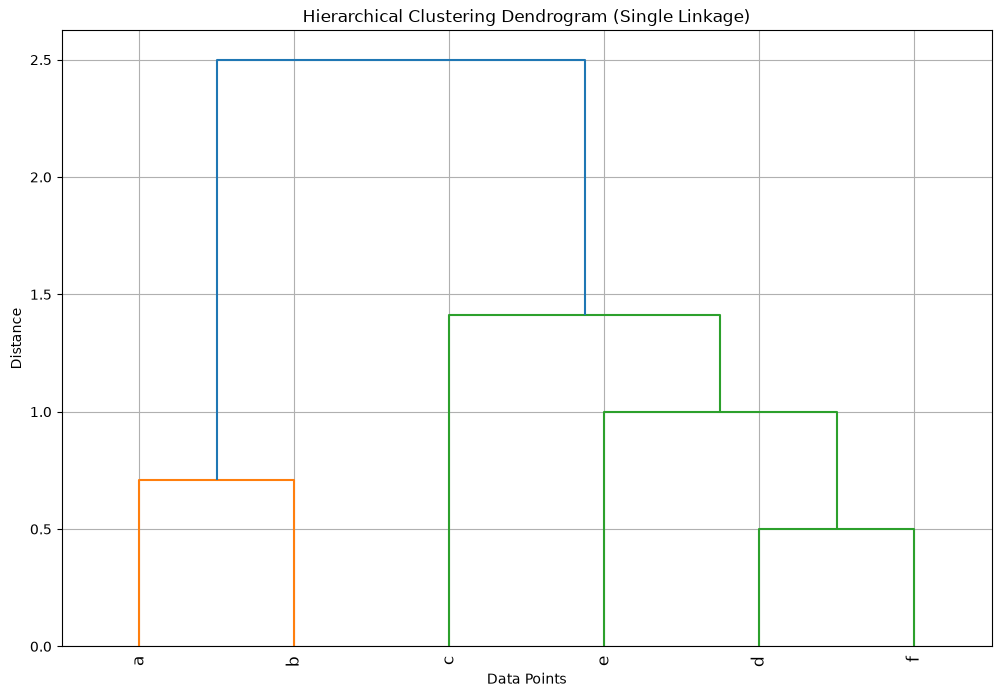

In [19]:
# 5. Plot Dendrogram
plt.figure(figsize=(12, 8))
plt.title("Hierarchical Clustering Dendrogram (Single Linkage)")
dendrogram(linked, labels=['a', 'b', 'c', 'd', 'e', 'f'], leaf_rotation=90)
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

### Penjelasan Code diatas:

- plt.figure(figsize=(12, 8)) berfungsi membuat area gambar dengan ukuran 
- plt.title(...) berfungsi memberi judul pada grafik
- dendrogram(linked, ...) berfungsi menggambar diagram pohon dari hasil clustering yang tersimpan di variabel linked
- labels=['a', 'b', 'c', 'd', 'e', 'f'] berfungsi memberi nama pada setiap titik di bagian bawah dendrogram
- leaf_rotation=90 berfungsi memutar label titik sebesar 90 derajat agar posisinya tegak
- plt.xlabel("Data Points") berfungsi memberi nama sumbu x yaitu titik data
- plt.ylabel("Distance") berfungsi memberi nama sumbu y yaitu jarak penggabungan cluster
- plt.grid(True) berfungsi menampilkan garis bantu (grid) agar nilai jarak lebih mudah di baca
- plt.show() berfungsi menampilkan grafik dendrogram nya

In [20]:

import pandas as pd
df = pd.read_csv("Mall_Customers.csv")
df.head()


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### Penjelasan Code diatas:

- import pandas as pd berfungsi memanggil library pandas untuk mengolah data tabel
- pd.read_csv("Mall_Customers.csv") berfungsi membaca file dataset Mall_Customers.csv dan menyimpan nya ke variabel df dalam bentuk DataFrame
- df.head() berfungsi menampilkan 5 baris pertama dari dataset untuk melihat gambaran isi data nya

In [21]:
x = df.iloc[:, [3, 4]].values

### Penjelasan Code diatas 

- df.iloc[:, [3, 4]] berfungsi memilih data berdasarkan posisi kolom
- tanda : artinya mengambil semua baris
- [3, 4] artinya mengambil kolom ke-4 dan ke-5 (indeks dimulai dari 0), yaitu Annual Income (k$) dan Spending Score (1-100)
- .values berfungsi mengubah data tersebut dari DataFrame menjadi array NumPy
- hasil nya disimpan ke variabel x yang akan digunakan sebagai data untuk clustering

In [22]:
from sklearn.preprocessing import StandardScaler
data_scaler = StandardScaler()
scaled_data = data_scaler.fit_transform(x)
scaled_data.shape

(200, 2)

###  Penjelasan Code di atas:


- from sklearn.preprocessing import StandardScaler berfungsi memanggil StandardScaler dari library scikit-learn untuk menstandarisasi data
- data_scaler = StandardScaler() berfungsi membuat objek scaler dan menyimpan nya ke variabel data_scaler
- data_scaler.fit_transform(x) berfungsi menghitung rata-rata dan standar deviasi dari setiap kolom (fit), lalu mengubah data agar memiliki rata-rata 0 dan standar deviasi 1 (transform)
- standarisasi dilakukan agar Annual Income dan Spending Score memiliki skala yang sama, sehingga tidak ada kolom yang lebih mendominasi saat perhitungan jarak
- hasil nya disimpan ke variabel scaled_data
- scaled_data.shape berfungsi menampilkan ukuran data, yaitu (200, 2) artinya 200 baris dan 2 kolom

In [23]:
from scipy.cluster.hierarchy import linkage, dendrogram
clustering = linkage(scaled_data, method="complete", metric="euclidean")

### Penjelasan Code diatas:

- from scipy.cluster.hierarchy import linkage, dendrogram berfungsi memanggil fungsi linkage untuk clustering dan dendrogram untuk menggambar hasil nya
- linkage(scaled_data, ...) berfungsi melakukan hierarchical clustering pada data yang sudah distandarisasi
- method="complete" artinya menggunakan complete linkage, yaitu jarak antar cluster diukur dari jarak dua titik yang paling jauh di antara kedua cluster
- metric="euclidean" artinya jarak antar titik dihitung menggunakan rumus jarak Euclidean
- hasil nya disimpan ke variabel clustering dalam bentuk matrik berukuran 199 x 4 (jumlah data 200 dikurangi 1)
- setiap baris pada clustering berisi: cluster pertama, cluster kedua, jarak penggabungan, dan jumlah titik dalam cluster baru

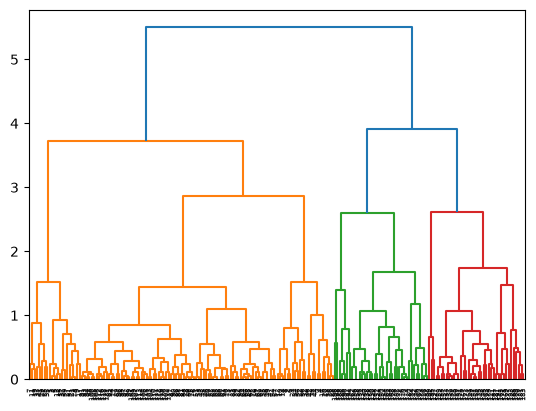

In [24]:
import matplotlib.pyplot as plt
dendrogram(clustering)
plt.show()

### Penjelasan Code diatas:

- import matplotlib.pyplot as plt berfungsi memanggil library matplotlib untuk menampilkan grafik
- dendrogram(clustering) berfungsi menggambar diagram pohon dari hasil clustering yang tersimpan di variabel clustering
- karena tidak diberi labels, bagian bawah dendrogram akan menampilkan nomor indeks data (0 sampai 199)
- plt.show() berfungsi menampilkan grafik dendrogram nya
- cara membaca dendrogram: sumbu x adalah data pelanggan dan sumbu y adalah jarak penggabungan cluster, semakin tinggi garis penggabungan semakin jauh jarak antar cluster
- jumlah cluster bisa ditentukan dengan menarik garis horizontal pada jarak yang memotong garis vertikal terpanjang tanpa terpotong garis horizontal lain

### TUGAS PRAKTIKUM

Membandingkan hasil plot dendrogram single linkage dengan complete linkage
dan average linkage

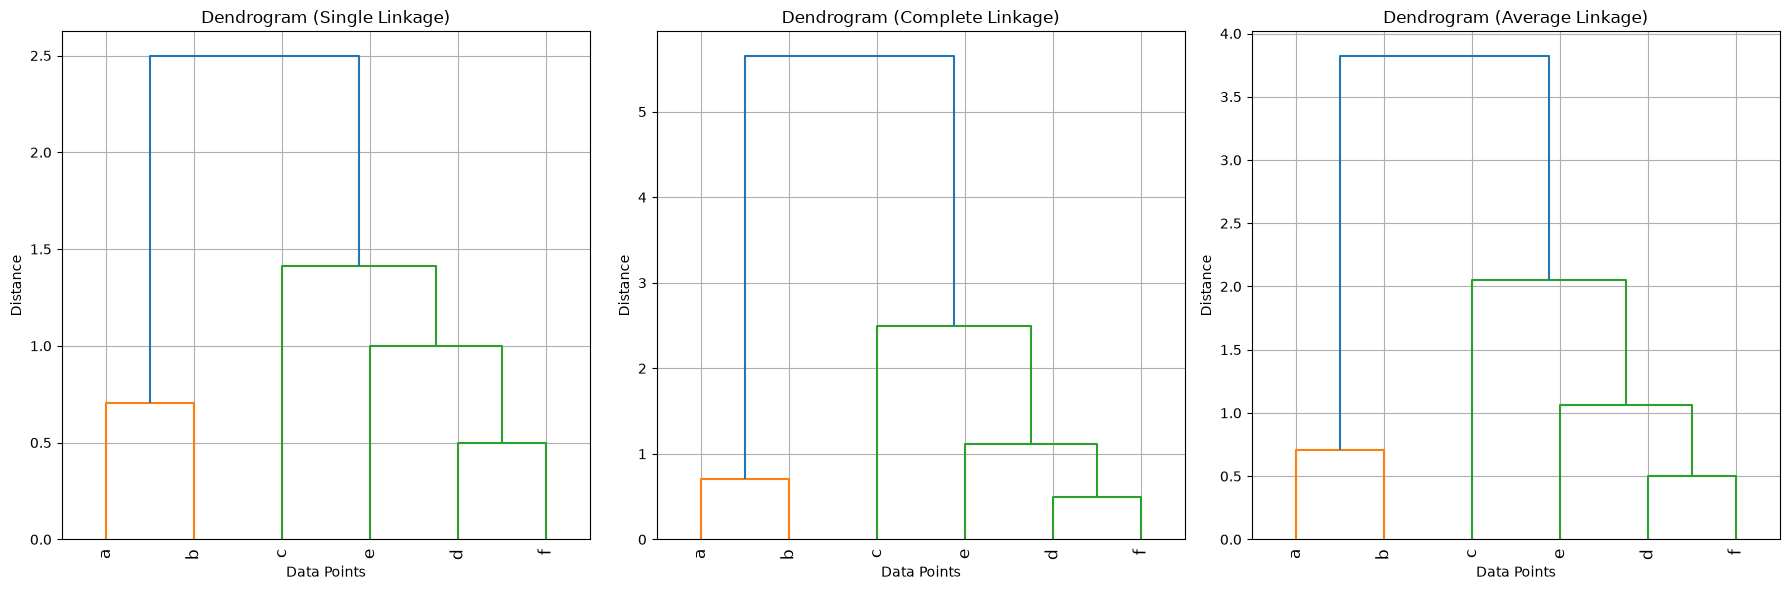

In [ ]:

methods = ['single', 'complete', 'average']
labels = ['a', 'b', 'c', 'd', 'e', 'f']

plt.figure(figsize=(18, 6))
for i, method in enumerate(methods):
    linked = linkage(data, method=method)
    plt.subplot(1, 3, i + 1)
    plt.title(f"Dendrogram ({method.capitalize()} Linkage)")
    dendrogram(linked, labels=labels, leaf_rotation=90)
    plt.xlabel("Data Points")
    plt.ylabel("Distance")
    plt.grid(True)

plt.tight_layout()
plt.show()

### Penjelasan Code diatas:

- methods berisi tiga metode linkage yang akan dibandingkan yaitu single, complete, dan average
- plt.figure(figsize=(18, 6)) berfungsi membuat area gambar yang lebar agar tiga dendrogram bisa ditampilkan berdampingan
- for i, method in enumerate(methods) berfungsi melakukan perulangan untuk setiap metode
- linkage(data, method=method) berfungsi melakukan clustering dengan metode yang sedang diproses
- plt.subplot(1, 3, i + 1) berfungsi membagi gambar menjadi 1 baris dan 3 kolom, lalu memilih posisi grafik ke-1, 2, atau 3
- plt.tight_layout() berfungsi merapikan jarak antar grafik agar tidak saling bertumpuk